Refer to the `readme.md` and `SF-36 appendix.md` files for detailed information on this analysis

# 2. Python project
### Aim
The aim of this code is to compute Physical Component Summary (PCS) and Mental Component Summary (MCS) scores and compare their distribution at 3 and 12 months using boxplots to assess changes over time.  

## 3.Code

### 3.1. Setup


In [23]:
# If necesary, install the required libraries using pip:
# !pip install pandas matplotlib pingouin

# Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import pingouin as pg

# Load the data from the CSV file
bazP = pd.read_csv("data/bazP_scores.csv")

### 3.2. Calculation of the Physical and Mental Component Summay (PCS and MCS) at 3 and 12 months
Z-scores were first computed for each SF-36 dimension using reference values from the French general population.
They are calculated as:

$$
Z = \frac{\text{Observed dimension score} - \text{Mean of the French general population}}{\text{Standard deviation of the French general population}}
$$



In [24]:
## Calculate the Z-scores for each SF-36 subscale at 3 months
# Physical Functioning
bazP["PF_Z_3m"] = (bazP["PFtransformed_3m"] - 85.3) / 22.3

# Role Physical
bazP["RP_Z_3m"] = (bazP["RPtransformed_3m"] - 82.2) / 32.2

# Bodily Pain
bazP["BP_Z_3m"] = (bazP["BPtransformed_3m"] - 73.0) / 24.6

# General Health
bazP["GH_Z_3m"] = (bazP["GHtransformed_3m"] - 67.8) / 18.9

# Vitality
bazP["VT_Z_3m"] = (bazP["VTtransformed_3m"] - 57.4) / 18.0

# Social Functioning
bazP["SF_Z_3m"] = (bazP["SFtransformed_3m"] - 80.9) / 21.2

# Role Emotional
bazP["RE_Z_3m"] = (bazP["REtransformed_3m"] - 82.0) / 32.9

# Mental Health
bazP["MH_Z_3m"] = (bazP["MHtransformed_3m"] - 66.7) / 17.7


The Physical and Mental Component Summary (PCS and MCS) scores are then derived from the SF-36 dimension z-scores using weighted linear combinations of domain-specific coefficients. These coefficients are derived from the SF-36 scoring algorithm and reflect the relative contribution of each health dimension to overall physical or mental health status.

$$
PCS = \left[(PF_z \times 0.42402) + (RP_z \times 0.35119) + (BP_z \times 0.31754) + (GH_z \times 0.24954) + (VT_z \times 0.02877) + (SF_z \times -0.00753) + (RE_z \times -0.19206) + (MH_z \times -0.22069)\right] \times 10 + 50
$$

$$
MCS = \left[(PF_z \times -0.22999) + (RP_z \times -0.12329) + (BP_z \times -0.09731) + (GH_z \times -0.01571) + (VT_z \times 0.23534) + (SF_z \times 0.26876) + (RE_z \times 0.43407) + (MH_z \times 0.48581)\right] \times 10 + 50
$$


In [25]:
## Calculate the Physical Component Summary (PCS) and Mental Component Summary (MCS) scores at 3 months
# Physical Component Summary (PCS)
bazP["PhysicalComponentScale_z_3m"] = (
    (
        (bazP["PF_Z_3m"] * 0.42402) +
        (bazP["RP_Z_3m"] * 0.35119) +
        (bazP["BP_Z_3m"] * 0.31754) +
        (bazP["VT_Z_3m"] * 0.02877) +
        (bazP["GH_Z_3m"] * 0.24954) +
        (bazP["SF_Z_3m"] * -0.00753) +
        (bazP["MH_Z_3m"] * -0.22069) +
        (bazP["RE_Z_3m"] * -0.19206)         
        
    ) * 10
) + 50

print(bazP["PhysicalComponentScale_z_3m"].describe())


# Mental Component Summary (MCS)
bazP["MentalComponentScale_z_3m"] = (
    (
        (bazP["PF_Z_3m"] * -0.22999) +
        (bazP["RP_Z_3m"] * -0.12329) +
        (bazP["BP_Z_3m"] * -0.09731) +
        (bazP["SF_Z_3m"] * 0.26876) +
        (bazP["MH_Z_3m"] * 0.48581) +
        (bazP["RE_Z_3m"] * 0.43407) +
        (bazP["VT_Z_3m"] * 0.23534) +
        (bazP["GH_Z_3m"] * -0.01571)
    ) * 10
) + 50

print(bazP["MentalComponentScale_z_3m"].describe())

count    26.000000
mean     36.886946
std       9.100394
min      19.782135
25%      30.729874
50%      35.539706
75%      40.133625
max      54.923130
Name: PhysicalComponentScale_z_3m, dtype: float64
count    26.000000
mean     44.149032
std      11.342752
min      16.946206
25%      36.804500
50%      44.265013
75%      51.635610
max      64.355801
Name: MentalComponentScale_z_3m, dtype: float64


In [26]:
## Calculate the Z-scores for each SF-36 subscale at 12 months
# Physical Functioning
bazP["PF_Z_12m"] = (bazP["PFtransformed_12m"] - 85.3) / 22.3
print(bazP["PF_Z_12m"].describe())

# Role Physical
bazP["RP_Z_12m"] = (bazP["RPtransformed_12m"] - 82.2) / 32.2
print(bazP["RP_Z_12m"].describe())

# Bodily Pain
bazP["BP_Z_12m"] = (bazP["BPtransformed_12m"] - 73.0) / 24.6
print(bazP["BP_Z_12m"].describe())

# General Health
bazP["GH_Z_12m"] = (bazP["GHtransformed_12m"] - 67.8) / 18.9
print(bazP["GH_Z_12m"].describe())

# Vitality
bazP["VT_Z_12m"] = (bazP["VTtransformed_12m"] - 57.4) / 18.0
print(bazP["VT_Z_12m"].describe())

# Social Functioning
bazP["SF_Z_12m"] = (bazP["SFtransformed_12m"] - 80.9) / 21.2
print(bazP["SF_Z_12m"].describe())

# Role Emotional
bazP["RE_Z_12m"] = (bazP["REtransformed_12m"] - 82.0) / 32.9
print(bazP["RE_Z_12m"].describe())

# Mental Health
bazP["MH_Z_12m"] = (bazP["MHtransformed_12m"] - 66.7) / 17.7
print(bazP["MH_Z_12m"].describe())

count    30.000000
mean     -1.166293
std       1.391039
min      -3.825112
25%      -2.199552
50%      -1.134529
75%       0.070628
max       0.659193
Name: PF_Z_12m, dtype: float64
count    27.000000
mean     -0.856223
std       1.345398
min      -2.552795
25%      -2.552795
50%      -1.000000
75%       0.552795
max       0.552795
Name: RP_Z_12m, dtype: float64
count    30.000000
mean     -0.867209
std       0.792302
min      -2.560976
25%      -1.341463
50%      -0.528455
75%      -0.528455
max       0.691057
Name: BP_Z_12m, dtype: float64
count    30.000000
mean     -0.474427
std       0.679583
min      -1.470899
25%      -0.941799
50%      -0.412698
75%       0.050265
max       0.910053
Name: GH_Z_12m, dtype: float64
count    30.000000
mean     -0.383333
std       0.907919
min      -2.633333
25%      -0.897222
50%      -0.318519
75%       0.422222
max       0.977778
Name: VT_Z_12m, dtype: float64
count    30.000000
mean     -0.612421
std       1.206215
min      -3.226415
25%      

In [27]:
## Calculate the Physical Component Summary (PCS) and Mental Component Summary (MCS) scores at 12 months
# Physical Component Summary (PCS) - 12 months
bazP["PhysicalComponentScale_z_12m"] = (
    (
        (bazP["PF_Z_12m"] * 0.42402) +
        (bazP["RP_Z_12m"] * 0.35119) +
        (bazP["BP_Z_12m"] * 0.31754) +
        (bazP["SF_Z_12m"] * -0.00753) +
        (bazP["MH_Z_12m"] * -0.22069) +
        (bazP["RE_Z_12m"] * -0.19206) +
        (bazP["VT_Z_12m"] * 0.02877) +
        (bazP["GH_Z_12m"] * 0.24954)
    ) * 10
) + 50

print(bazP["PhysicalComponentScale_z_12m"].describe())


# Mental Component Summary (MCS) - 12 months
bazP["MentalComponentScale_z_12m"] = (
    (
        (bazP["PF_Z_12m"] * -0.22999) +
        (bazP["RP_Z_12m"] * -0.12329) +
        (bazP["BP_Z_12m"] * -0.09731) +
        (bazP["SF_Z_12m"] * 0.26876) +
        (bazP["MH_Z_12m"] * 0.48581) +
        (bazP["RE_Z_12m"] * 0.43407) +
        (bazP["VT_Z_12m"] * 0.23534) +
        (bazP["GH_Z_12m"] * -0.01571)
    ) * 10
) + 50

print(bazP["MentalComponentScale_z_12m"].describe())

# Export the data
bazP.to_csv("results/bazP_scores_with_PCS_MCS.csv", index=False)

count    26.000000
mean     40.467545
std       6.978514
min      27.171154
25%      35.728846
50%      39.803714
75%      46.304618
max      53.519852
Name: PhysicalComponentScale_z_12m, dtype: float64
count    26.000000
mean     48.509823
std       9.610724
min      29.681414
25%      42.691135
50%      47.984336
75%      56.411154
max      67.146391
Name: MentalComponentScale_z_12m, dtype: float64


### 3.3. Visualization of the distribution of PCS and MCS at 3 and 12 months, generating boxplots

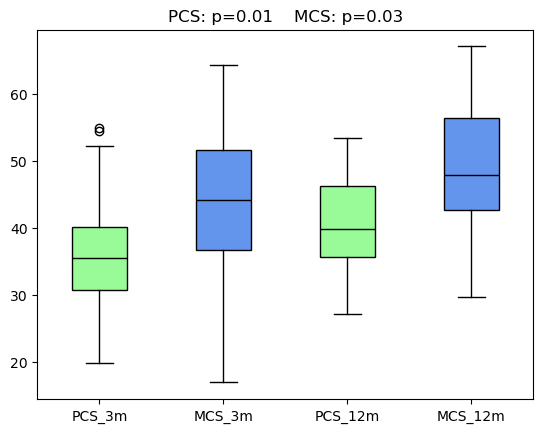

In [28]:
# Create a boxplot for the Physical Component Summary (PCS) and Mental Component Summary (MCS) scores at 3 and 12 months
## Create a list of the columns to be plotted
cols = [
    "PhysicalComponentScale_z_3m",
    "MentalComponentScale_z_3m",
    "PhysicalComponentScale_z_12m",
    "MentalComponentScale_z_12m"
]
## Extract the data for the boxplot, ensuring that we drop any NA
data = [bazP[col].dropna().values for col in cols]

## Calculate the p-values for the Wilcoxon signed-rank test comparing the PCS and MCS scores at 3 and 12 months
p_pcs = pg.wilcoxon(bazP["PhysicalComponentScale_z_3m"], bazP["PhysicalComponentScale_z_12m"])["p_val"].values[0]
p_mcs = pg.wilcoxon(bazP["MentalComponentScale_z_3m"], bazP["MentalComponentScale_z_12m"])["p_val"].values[0]

## Create the boxplot
bp = plt.boxplot(data, patch_artist=True)

plt.setp(bp["boxes"][0], facecolor="palegreen")
plt.setp(bp["boxes"][1], facecolor="cornflowerblue")
plt.setp(bp["boxes"][2], facecolor="palegreen")
plt.setp(bp["boxes"][3], facecolor="cornflowerblue")
plt.setp(bp["medians"], color="black")
plt.xticks([1,2,3,4], ["PCS_3m", "MCS_3m", "PCS_12m", "MCS_12m"])
plt.title(f"PCS: p={p_pcs:.2f}    MCS: p={p_mcs:.2f}")
plt.savefig(r"results/boxplot.png", dpi=300, bbox_inches="tight")
plt.show()